# Projekt na przedmiot `Inteligentne technologie w przemyśle`

**Temat:** `Przewidywanie awarii i klasyfikacja usterek w sieciach elektroenergetycznych (Power Internet of Things - PIoT)`

Użyty dataset: https://www.kaggle.com/datasets/programmer3/piot-sensor-for-fault-prediction

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## ETAP 1 & 2: WCZYTANIE I PRZYGOTOWANIE DANYCH

In [2]:
# ==========================================
# ETAP 1 & 2: WCZYTANIE I PRZYGOTOWANIE DANYCH
# ==========================================

DATASET_PATH = "data/PIoT_fault_dataset.csv"

if os.path.exists(DATASET_PATH):
    print(f"Wczytywanie zbioru danych: {DATASET_PATH}")
    df = pd.read_csv(DATASET_PATH)
else:
    print(f"Nie znaleziono pliku '{DATASET_PATH}'.")
    exit()

# Wyświetlenie podstawowych informacji o strukturze danych
print("\n--- Podgląd danych (Pierwsze 5 wierszy) ---")
# print(df.head())
df.head()


Wczytywanie zbioru danych: data/PIoT_fault_dataset.csv

--- Podgląd danych (Pierwsze 5 wierszy) ---


,Timestamp,Node_ID,Voltage,Current,Frequency,Power,Temperature,Load,Fault_Label
0,0,7,237.987383,11.186337,50.070573,26.622071,30.124274,0.525255,0
1,1,20,227.526770,8.176694,50.039255,18.604167,37.414614,0.612410,0
2,2,29,221.099374,7.525063,50.084475,16.637867,35.471717,0.701497,0
3,3,15,221.757548,7.725553,50.103033,17.131996,39.171222,0.709043,0
4,4,11,223.082223,11.021295,50.099417,24.586549,34.394708,0.779392,0


In [3]:
# Sprawdzenie rozkładu klas awarii w zbiorze
# (0 = normalna praca sieci, pozostałe wartości różne typy awarii)
print("\n--- Rozkład klas usterek w zbiorze ---")
print(round(df["Fault_Label"].value_counts(normalize=True) * 100, 3))



--- Rozkład klas usterek w zbiorze ---
Fault_Label
0    96.395
3     2.212
1     1.393
Name: proportion, dtype: float64


In [4]:
# Sprawdzenie braków danych:
print("\n--- Sprawdzenie czy dane zawierają brakujące wartości (NaN) ---")
print(df.isna().sum())

if df.isna().sum().sum() != 0:
    # Czyszczenie danych: usunięcie wierszy z brakami (NaN)
    df = df.dropna()



--- Sprawdzenie czy dane zawierają brakujące wartości (NaN) ---
Timestamp      0
Node_ID        0
Voltage        0
Current        0
Frequency      0
Power          0
Temperature    0
Load           0
Fault_Label    0
dtype: int64


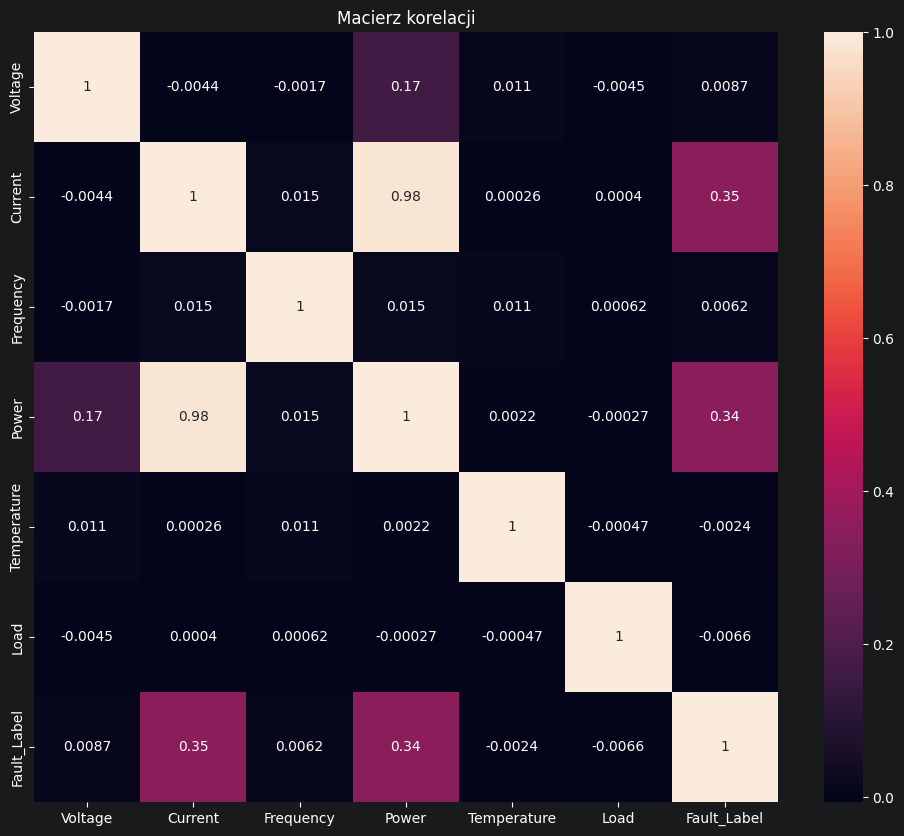

In [5]:
# Sprawdzenie kolerlacji zmiennych numerycznych
corr_df = df.drop(columns=['Timestamp', 'Node_ID']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True)
plt.title("Macierz korelacji")
plt.show()


In [6]:
# Sprawdzenie typów danych dla cech w zbiorze danych
print("Typy danych dla poszczególnych cech w zbiorze danych:")
df.columns.tolist()
df.dtypes


Typy danych dla poszczególnych cech w zbiorze danych:


Timestamp        int64
Node_ID          int64
Voltage        float64
Current        float64
Frequency      float64
Power          float64
Temperature    float64
Load           float64
Fault_Label      int64
dtype: object

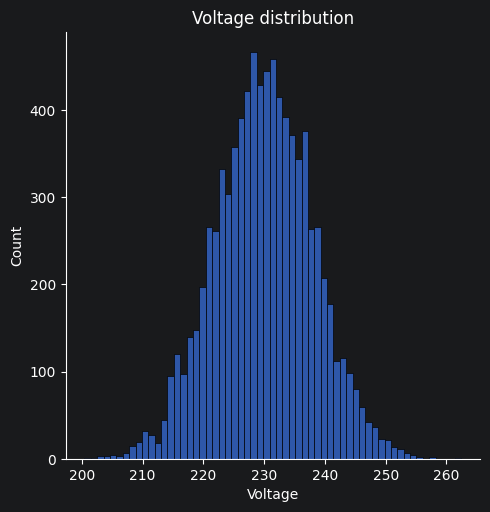

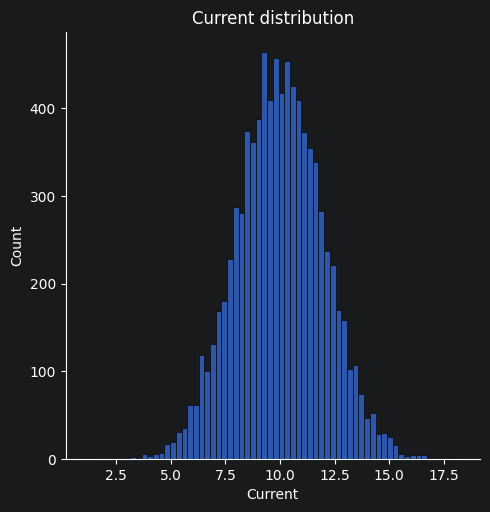

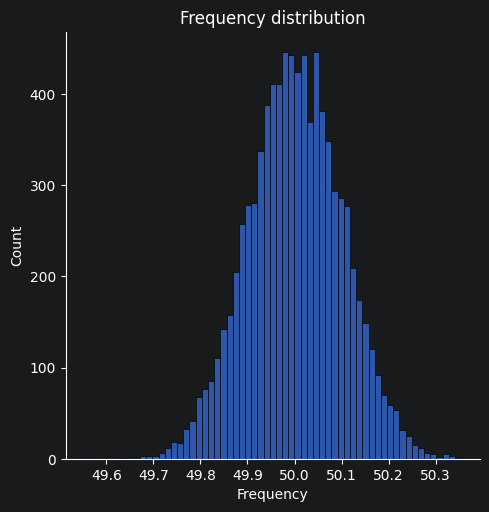

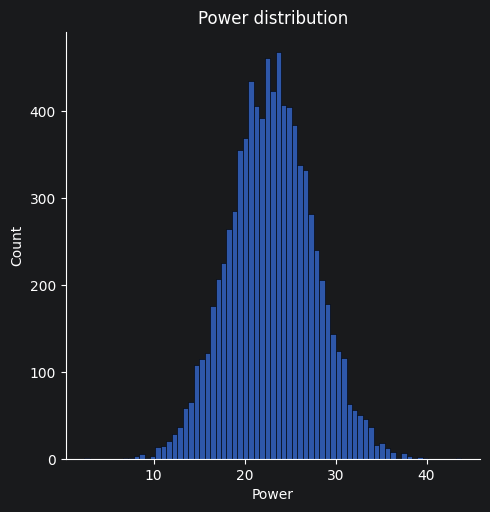

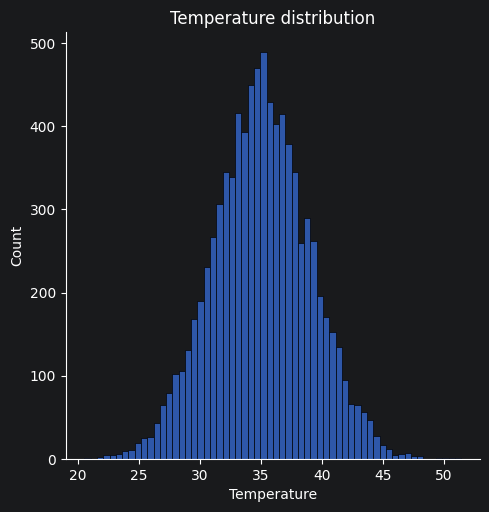

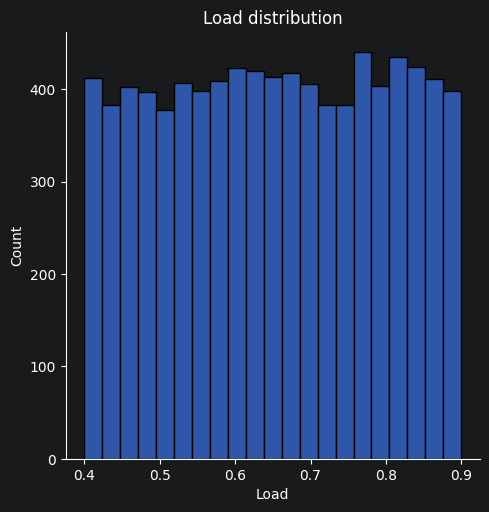

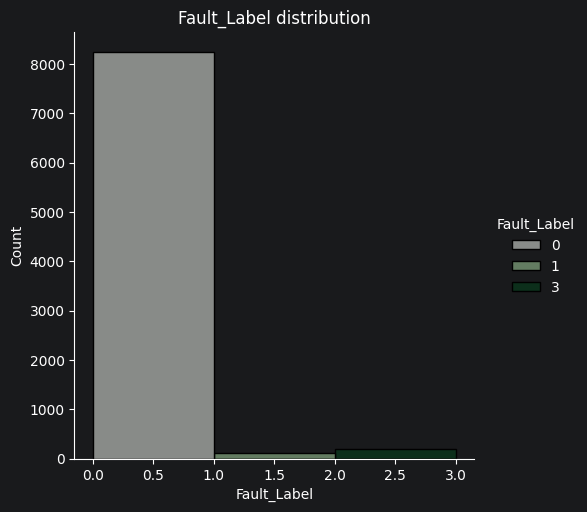

In [7]:
# Rozkład zmiennych numerycznych
num_features = df.drop(columns=["Timestamp", "Node_ID"], axis=1).columns.tolist()

for feature in num_features:
    if feature == "Fault_Label":
        sns.displot(data=df, x=feature, bins=3, kind="hist", hue="Fault_Label", palette="Greens")
    else:
        sns.displot(data=df, x=feature, kind="hist")
    plt.title(f"{feature} distribution")
    plt.show()


In [8]:
# Statystyki opisowe zmiennych numerycznych
df[num_features].drop(columns="Fault_Label", axis=1).describe().T


,count,mean,std,min,25%,50%,75%,max
Voltage,8543.0,229.981722,8.016217,200.427025,224.594474,230.019753,235.430334,262.420401
Current,8543.0,9.989067,1.979180,1.042955,8.642856,9.981879,11.330231,18.295790
Frequency,8543.0,50.001199,0.100024,49.553455,49.934020,50.000761,50.069366,50.354254
Power,8543.0,22.972335,4.622273,2.400380,19.857725,22.949001,26.050773,43.805910
Temperature,8543.0,35.012692,3.965321,20.528243,32.351360,34.997306,37.621723,51.397801
Load,8543.0,0.651865,0.143945,0.400064,0.528316,0.651129,0.777661,0.899931


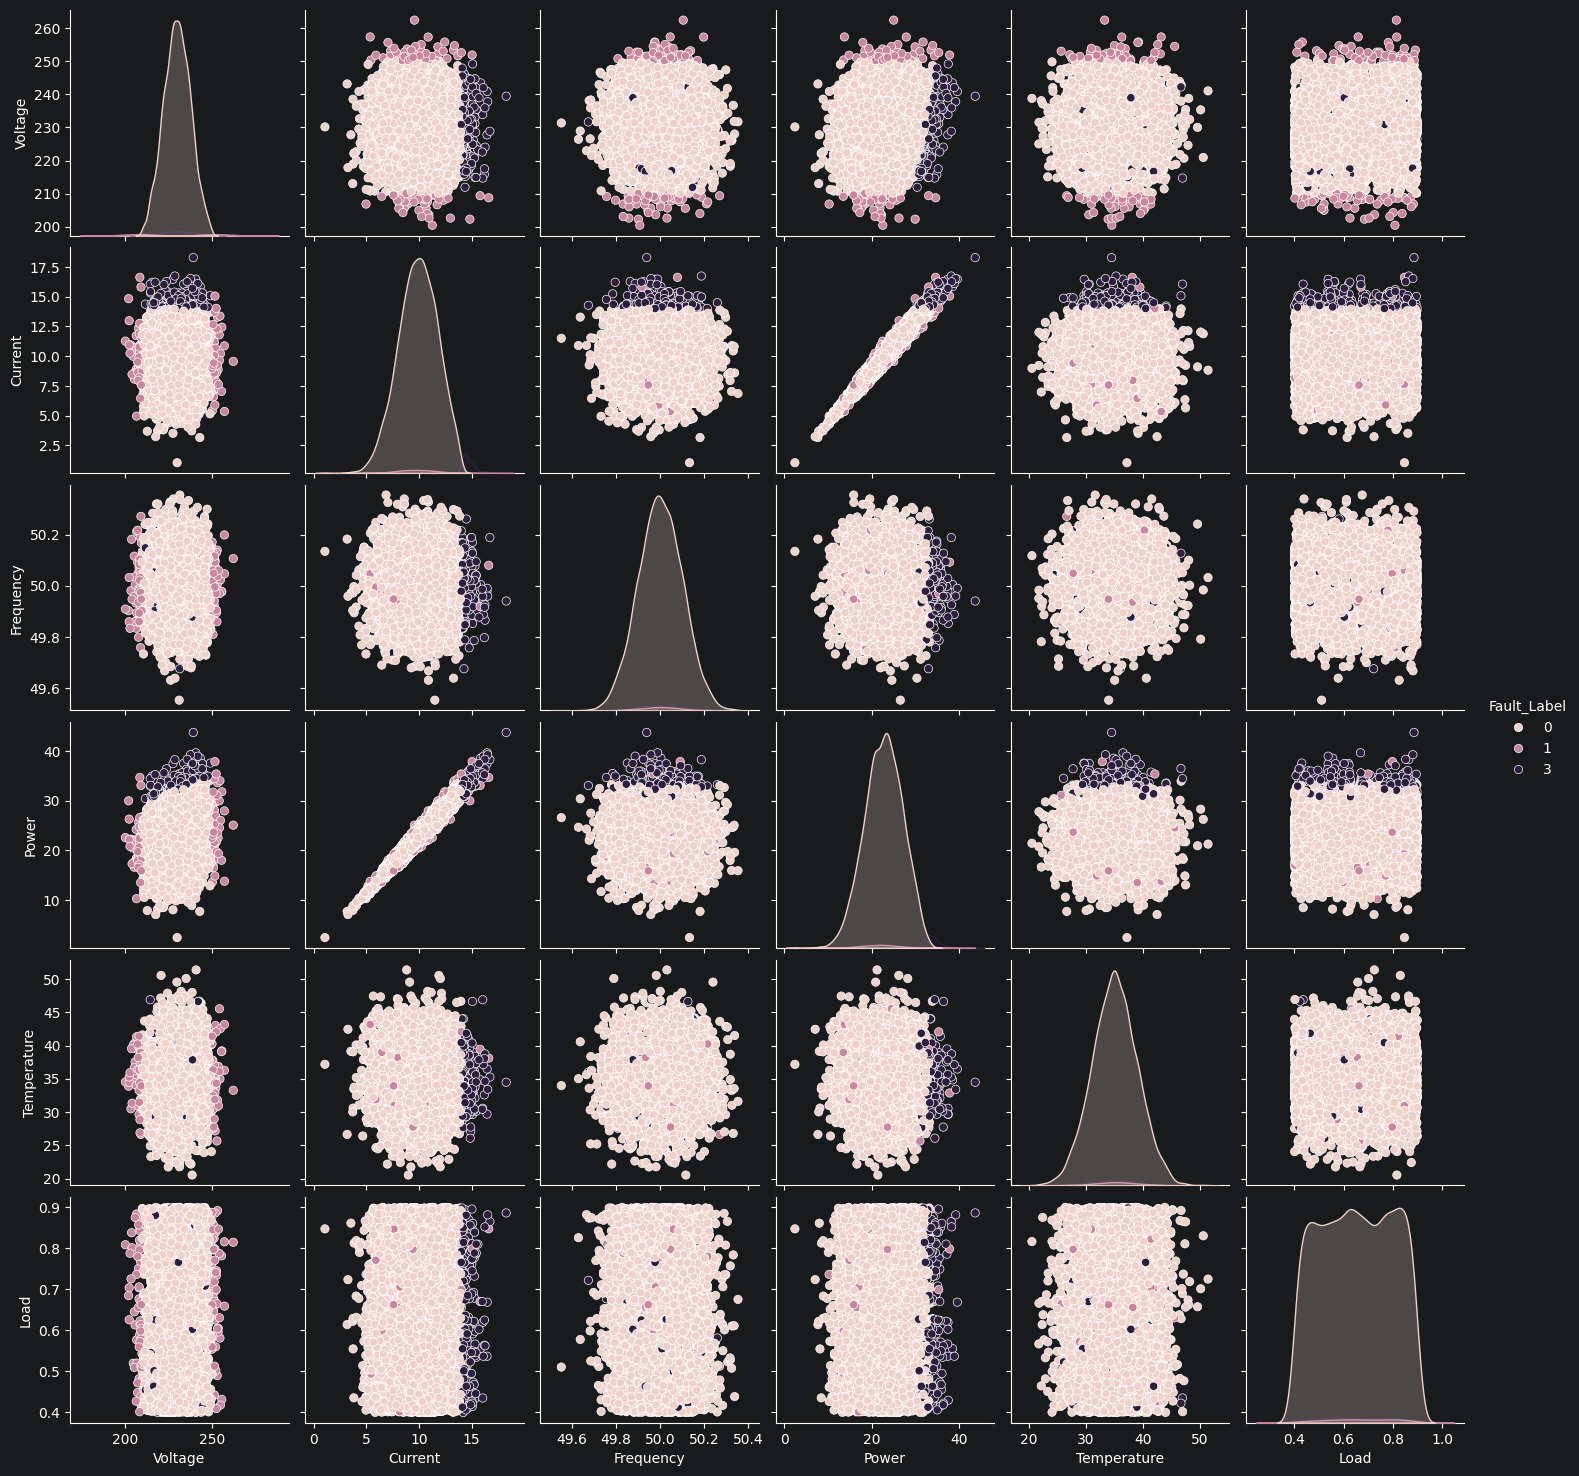

In [18]:
# Pairplot dla zmiennych numerycznych
sns.pairplot(data=df[num_features], hue="Fault_Label")
# plt.suptitle("Pair plot zmiennych numerycznych")
plt.show()


## ETAP 3: PRZYGOTOWANIE CECH DO MODELOWANIA

In [10]:
# ==========================================
# 3. PRZYGOTOWANIE CECH DO MODELOWANIA
# ==========================================

# Usuwamy kolumny identyfikacyjne i czasowe, zostawiamy tylko odczyty z sensorów
X = df.drop(columns=["Timestamp", "Node_ID", "Fault_Label"])
y_multi = df["Fault_Label"]

# ETAP I: Tworzenie etykiety binarnej dla priorytetowego wykrywania JAKIEJKOLWIEK awarii
# 0 - Normalna praca, 1 - Awaria (dowolny typ: 1 lub 3)
y_bin = (y_multi > 0).astype(int)

# Podział na zbiór treningowy i testowy (z zachowaniem proporcji klas - stratify)
X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = (
    train_test_split(
        X, y_bin, y_multi, test_size=0.2, random_state=42, stratify=y_bin
    )
)

# Skalowanie cech (niezbędne m.in. dla Regresji Logistycznej)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## ETAP 4: DEFINICJA I TRENOWANIE 3 MODELI (ETAP I)

In [11]:
# ==========================================
# 4. DEFINICJA I TRENOWANIE 3 MODELI (ETAP I)
# ==========================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", random_state=42, max_iter=1000
    ),
}

# Słownik na wyniki modeli
model_predictions = {}

# Dostrajanie progu decyzyjnego w celu maksymalizacji czułości (Recall)
# Ustawiony na niski próg, zamiast standardowego 0.5 - model ma reagować na najmniejsze anomalie
CUSTOM_THRESHOLD = 0.15

print("--- TRENOWANIE I EWALUACJA ETAPU I (WYKRYWANIE AWARII) ---")
for name, model in models.items():
    # Trenowanie modelu binarnego
    model.fit(X_train_scaled, y_train_bin)

    # Pobranie prawdopodobieństwa wystąpienia awarii (klasy 1)
    pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Zastosowanie obniżonego progu decyzyjnego
    pred_custom = (pred_proba >= CUSTOM_THRESHOLD).astype(int)
    model_predictions[name] = pred_custom

    # Wyliczanie macierzy pomyłek
    cm = confusion_matrix(y_test_bin, pred_custom)
    missed_faults = cm[1, 0]  # False Negatives (Rzeczywista awaria uznana za stan normalny)

    print(f"\nModel: {name}")
    print(f"Liczba NIEWYKRYTYCH awarii (False Negatives): {missed_faults}")
    print(classification_report(y_test_bin, pred_custom, target_names=["Normalny", "Awaria"]))


--- TRENOWANIE I EWALUACJA ETAPU I (WYKRYWANIE AWARII) ---

Model: Random Forest
Liczba NIEWYKRYTYCH awarii (False Negatives): 0
              precision    recall  f1-score   support

    Normalny       1.00      1.00      1.00      1647
      Awaria       0.98      1.00      0.99        62

    accuracy                           1.00      1709
   macro avg       0.99      1.00      1.00      1709
weighted avg       1.00      1.00      1.00      1709


Model: Gradient Boosting
Liczba NIEWYKRYTYCH awarii (False Negatives): 0
              precision    recall  f1-score   support

    Normalny       1.00      1.00      1.00      1647
      Awaria       1.00      1.00      1.00        62

    accuracy                           1.00      1709
   macro avg       1.00      1.00      1.00      1709
weighted avg       1.00      1.00      1.00      1709


Model: Logistic Regression
Liczba NIEWYKRYTYCH awarii (False Negatives): 6
              precision    recall  f1-score   support

    Normalny

## ETAP 5: PORÓWNANIE WIZUALNE MODELI (KTÓRY MODEL LEPSZY?)

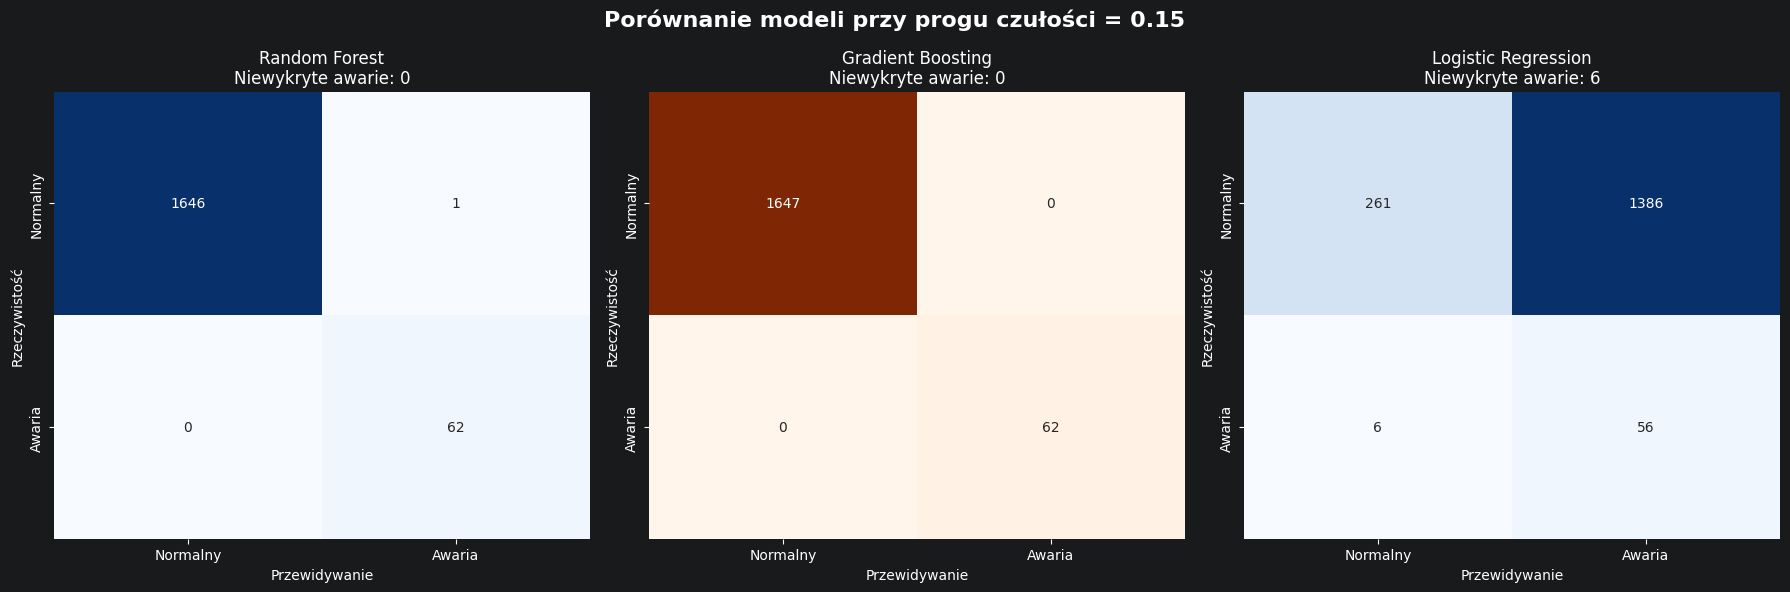

In [12]:
# ==========================================
# 5. PORÓWNANIE WIZUALNE MODELI - KTÓRY MODEL LEPSZY?
# ==========================================
fig, axis = plt.subplots(1, 3, figsize=(18, 6))
for i, (name, preds) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test_bin, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges" if name == "Gradient Boosting" else "Blues",
        ax=axis[i],
        cbar=False,
    )
    axis[i].set_title(f"{name}\nNiewykryte awarie: {cm[1,0]}")
    axis[i].set_xlabel("Przewidywanie")
    axis[i].set_ylabel("Rzeczywistość")
    axis[i].set_xticklabels(["Normalny", "Awaria"])
    axis[i].set_yticklabels(["Normalny", "Awaria"])

plt.suptitle(
    f"Porównanie modeli przy progu czułości = {CUSTOM_THRESHOLD}",
    fontsize=16,
    weight="bold",
)
plt.tight_layout()
plt.show()


## ETAP 6: KLASYFIKACJA TYPU AWARII (DLA WYKRYTYCH) - ETAP II


--- ETAP II: TRENOWANIE KLASYFIKATORA SPECYFICZNYCH USTEREK ---

Uruchamianie klasyfikacji typów usterek dla próbek oznaczonych jako awaria przez Gradient Boosting:
Wykryte i sklasyfikowane usterki szczegółowe:
 Typ usterki [1]: 23 przypadków
 Typ usterki [3]: 39 przypadków


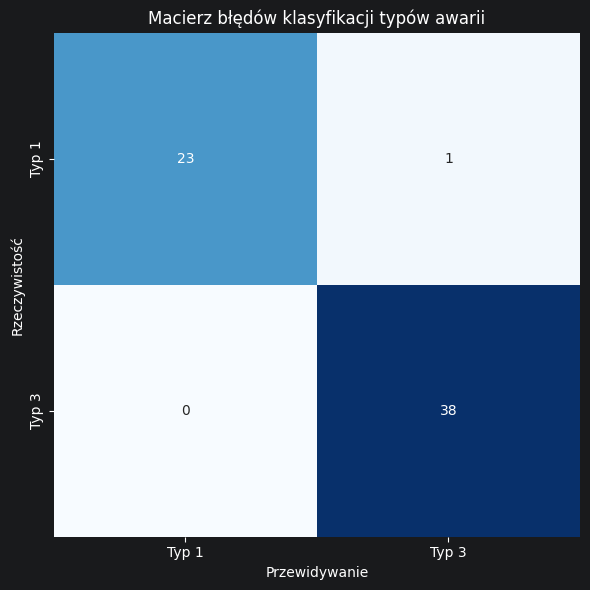

In [13]:
# ==========================================
# 6. ETAP II: KLASYFIKACJA TYPU AWARII (DLA WYKRYTYCH)
# ==========================================
print("\n--- ETAP II: TRENOWANIE KLASYFIKATORA SPECYFICZNYCH USTEREK ---")

# Do Etapu II bierzemy tylko te wiersze ze zbioru TRENINGOWEGO, w których faktycznie była awaria
train_faults_mask = y_train_multi > 0
X_train_faults = X_train_scaled[train_faults_mask]
y_train_faults = y_train_multi[train_faults_mask]

# Jako klasyfikator pomocniczy do typu usterek wybieramy np. sprawdzony Random Forest
fault_classifier = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)
fault_classifier.fit(X_train_faults, y_train_faults)

# Wybieramy najlepszy model z Etapu I (Gradient Boosting)
best_model_name = "Gradient Boosting"
detected_as_fault_mask = model_predictions[best_model_name] == 1

print(
    f"\nUruchamianie klasyfikacji typów usterek dla próbek oznaczonych jako awaria przez {best_model_name}:"
)

if np.sum(detected_as_fault_mask) > 0:
    X_test_detected_faults = X_test_scaled[detected_as_fault_mask]

    # Model z drugiego etapu przewiduje konkretne etykiety (1 lub 3)
    detailed_preds = fault_classifier.predict(X_test_detected_faults)

    # Zliczanie wyników
    unique, counts = np.unique(detailed_preds, return_counts=True)
    print("Wykryte i sklasyfikowane usterki szczegółowe:")
    for u, c in zip(unique, counts):
        print(f" Typ usterki [{u}]: {c} przypadków")

    y_test_detected_faults = y_test_multi[detected_as_fault_mask]

    cm = confusion_matrix(y_test_detected_faults, detailed_preds)

    fig, axis = plt.subplots(figsize=(6, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axis,
        cbar=False,
    )
    plt.title(f"Macierz błędów klasyfikacji typów awarii")
    axis.set_xlabel("Przewidywanie")
    axis.set_ylabel("Rzeczywistość")
    axis.set_xticklabels(["Typ 1", "Typ 3"])
    axis.set_yticklabels(["Typ 1", "Typ 3"])

    plt.tight_layout()
    plt.show()
else:
    print("Brak wykrytych awarii do dalszej szczegółowej analizy.")

In [14]:
pd.DataFrame(y_test_multi[detected_as_fault_mask]).value_counts()

Fault_Label
3              38
1              24
Name: count, dtype: int64

## ETAP 7: Istotność cech (Feature Importance)

### Wykrycie awarii

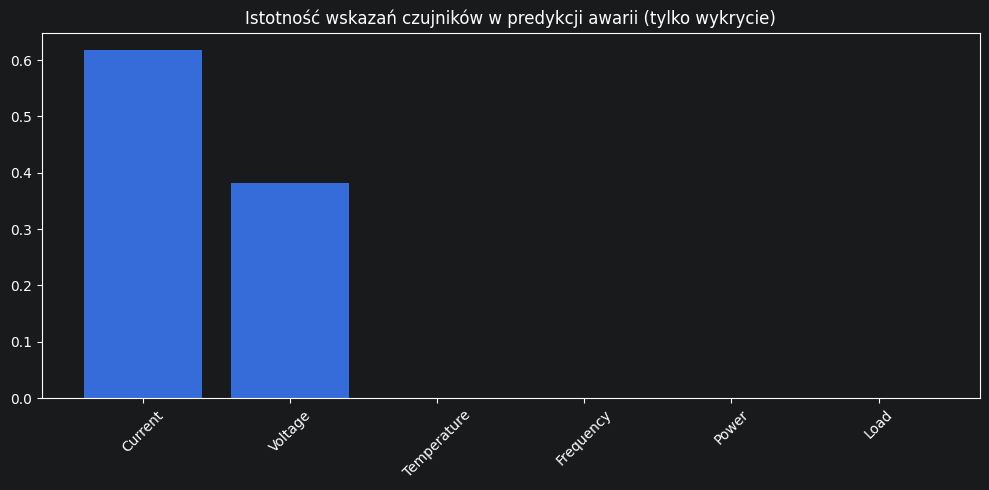

In [15]:
# Istotność cech (Feature Importance) - informacja, które dane z sensorów są kluczowe dla wykrywania awarii
best_model = models[best_model_name] # model detekcji awarii

if best_model_name == "Logistic Regression":
    exit()

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Istotność wskazań czujników w predykcji awarii (tylko wykrycie)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()


### Klasyfikacja typów awarii

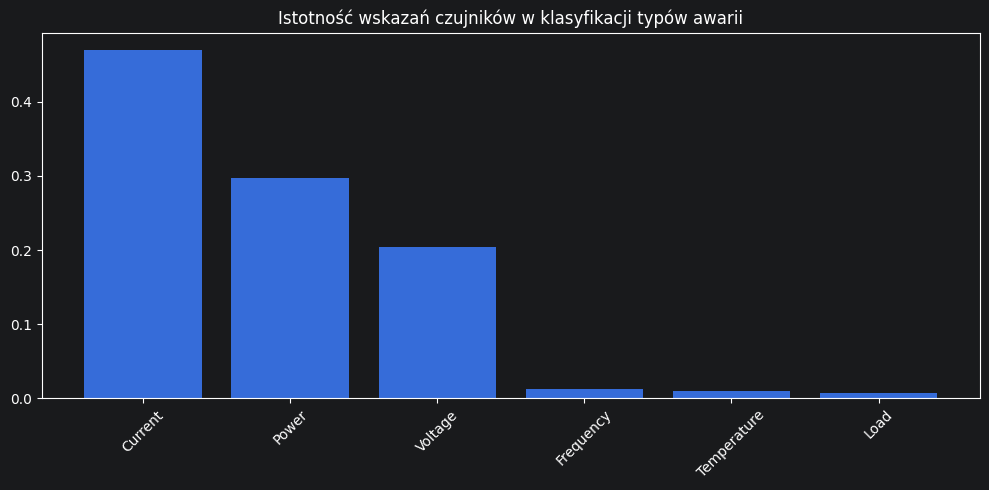

In [16]:
# Istotność cech (Feature Importance) - informacja, które dane z sensorów są kluczowe dla klasyfikacji typów awarii
importances = fault_classifier.feature_importances_ # dla modelu klasyfikacji typów awarii
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Istotność wskazań czujników w klasyfikacji typów awarii")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()